# 01 — Exploratory Data Analysis (EDA)

**Dataset:** NidaanKosha-100k-V1.0 — 100 000 Indian patients, long-format blood test records  
**Goal:** Understand the data, then perform a **stratified train/test split** that all downstream notebooks must use.

> ⚠️ The train/test IDs saved in this notebook are the **single source of truth** for the entire project.
> Never re-split in any downstream notebook.

In [1]:
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datasets import load_dataset
from sklearn.model_selection import train_test_split

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

PLOTS = '../results/plots'
SPLITS = '../data/splits'
os.makedirs(PLOTS, exist_ok=True)
os.makedirs(SPLITS, exist_ok=True)
print('Output dirs ready.')

c:\Users\Sreeansh Dash\OneDrive\Desktop\Projects\Machine_Learning_Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Output dirs ready.


## 1. Load Dataset

In [2]:
ds = load_dataset('ekacare/NidaanKosha-100k-V1.0')
df = ds['train'].to_pandas()
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head(3)

Shape: (6844304, 9)
Columns: ['document_id', 'age', 'gender', 'test_name', 'display_ranges', 'value', 'unit', 'specimen', 'loinc']


,document_id,age,gender,test_name,display_ranges,value,unit,specimen,loinc
0,a1ce7f03fca11a7351927f5d6d635552,72,female,% TRANSFERRIN SATURATION,NaN,25.4100,%,blood,2502-3
1,a1ce7f03fca11a7351927f5d6d635552,72,female,IRON,NaN,98.6000,ug/dl,NaN,2498-4
2,a1ce7f03fca11a7351927f5d6d635552,72,female,TOTAL IRON BINDING CAPACITY (TIBC),NaN,388.0000,ug/dl,blood,2500-7


## 2. Basic Exploration

In [3]:
print('=== dtypes ===')
print(df.dtypes)
print('\n=== Missing values ===')
mv = df.isnull().sum()
print(pd.DataFrame({'count': mv, 'pct': (mv/len(df)*100).round(2)}))
print(f'\nUnique patients : {df["document_id"].nunique():,}')
print(f'Total rows      : {len(df):,}')
print(f'Unique tests    : {df["test_name"].nunique():,}')
print(f'Unique LOINC    : {df["loinc"].nunique():,}')
print(f'Specimen types  : {sorted(df["specimen"].dropna().unique().tolist())}')

=== dtypes ===
document_id         str
age               int64
gender              str
test_name           str
display_ranges      str
value               str
unit                str
specimen            str
loinc               str
dtype: object

=== Missing values ===
                  count    pct
document_id           0   0.00
age                   0   0.00
gender                0   0.00
test_name             3   0.00
display_ranges   744316  10.87
value                 0   0.00
unit            1011831  14.78
specimen         400726   5.85
loinc            495826   7.24

Unique patients : 100,000
Total rows      : 6,844,304
Unique tests    : 64,327
Unique LOINC    : 581
Specimen types  : ['blood', 'body_fluid', 'ear_swab', 'eye_swab', 'patient', 'pus', 'respiratory', 'semen', 'stool', 'tissue', 'urine', 'urine_24h']


## 3. Age & Gender Distribution

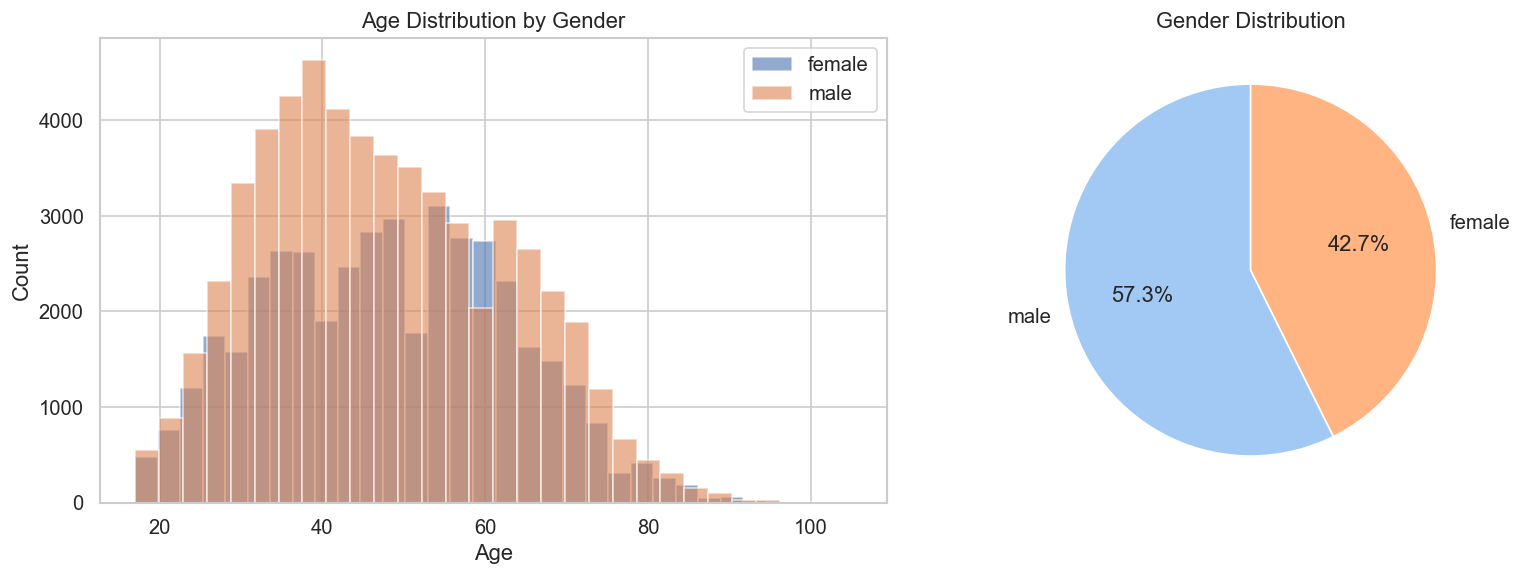

Age  — min:17  max:105  mean:47.8
gender
male      57346
female    42654
Name: count, dtype: int64


In [4]:
pts = df.drop_duplicates('document_id')[['document_id','age','gender']].copy()
pts['age'] = pd.to_numeric(pts['age'], errors='coerce')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for g, grp in pts.groupby('gender'):
    axes[0].hist(grp['age'].dropna(), bins=30, alpha=0.6, label=g)
axes[0].set_title('Age Distribution by Gender')
axes[0].set_xlabel('Age'); axes[0].set_ylabel('Count')
axes[0].legend()

gvc = pts['gender'].value_counts()
axes[1].pie(gvc.values, labels=gvc.index, autopct='%1.1f%%', startangle=90,
            colors=sns.color_palette('pastel')[:len(gvc)])
axes[1].set_title('Gender Distribution')
plt.tight_layout()
plt.savefig(f'{PLOTS}/age_gender_dist.png', bbox_inches='tight')
plt.show()
print(f'Age  — min:{pts.age.min():.0f}  max:{pts.age.max():.0f}  mean:{pts.age.mean():.1f}')
print(pts['gender'].value_counts())

## 4. Test Coverage per Patient

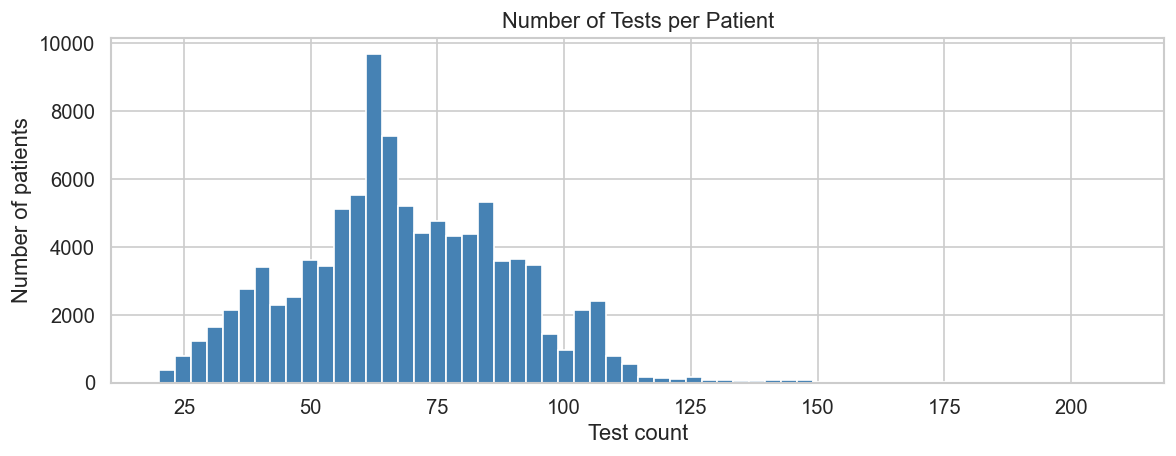

count    100000.000000
mean         68.443010
std          21.024149
min          20.000000
25%          55.000000
50%          67.000000
75%          83.000000
max         209.000000
Name: test_name, dtype: float64


In [5]:
tests_per_pt = df.groupby('document_id')['test_name'].count()
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(tests_per_pt.values, bins=60, color='steelblue', edgecolor='white')
ax.set_title('Number of Tests per Patient')
ax.set_xlabel('Test count'); ax.set_ylabel('Number of patients')
plt.tight_layout()
plt.savefig(f'{PLOTS}/tests_per_patient.png', bbox_inches='tight')
plt.show()
print(tests_per_pt.describe())

## 5. ⭐ Stratified Train / Test Split

Split happens **here**, on patient demographics only, **before** any per-test analysis.  
All downstream notebooks load `train_ids.csv` / `test_ids.csv` — they never re-split.

In [6]:
# ── patient-level dedup ──────────────────────────────────────────────────────
pts = df.drop_duplicates('document_id')[['document_id', 'age', 'gender']].copy()
pts['age'] = pd.to_numeric(pts['age'], errors='coerce')

# ── age bins ─────────────────────────────────────────────────────────────────
bins  = [0, 18, 35, 50, 65, 200]
labels = ['<18', '18-34', '35-49', '50-64', '65+']
pts['age_group'] = pd.cut(pts['age'], bins=bins, labels=labels, right=False)

# ── stratification key ───────────────────────────────────────────────────────
pts['strat_key'] = pts['gender'].astype(str) + '__' + pts['age_group'].astype(str)

# ── drop strata with < 2 patients ────────────────────────────────────────────
strat_counts = pts['strat_key'].value_counts()
valid_strata = strat_counts[strat_counts >= 2].index
pts_valid = pts[pts['strat_key'].isin(valid_strata)].copy()
dropped = len(pts) - len(pts_valid)
print(f'Dropped {dropped} patients from rare strata (< 2 patients in stratum)')

# ── split ────────────────────────────────────────────────────────────────────
train_pts, test_pts = train_test_split(
    pts_valid,
    test_size=0.2,
    random_state=42,
    stratify=pts_valid['strat_key']
)

train_ids = train_pts[['document_id']]
test_ids  = test_pts[['document_id']]

train_ids.to_csv(f'{SPLITS}/train_ids.csv', index=False)
test_ids.to_csv(f'{SPLITS}/test_ids.csv',  index=False)

print(f'\nTrain patients : {len(train_ids):,}')
print(f'Test  patients : {len(test_ids):,}')
print(f'\nSplit ratio    : {len(train_ids)/len(pts_valid)*100:.1f}% / {len(test_ids)/len(pts_valid)*100:.1f}%')

Dropped 0 patients from rare strata (< 2 patients in stratum)

Train patients : 80,000
Test  patients : 20,000

Split ratio    : 80.0% / 20.0%


In [7]:
# ── confirm proportions are preserved ────────────────────────────────────────
print('=== Gender proportions ===')
for name, subset in [('Full', pts_valid), ('Train', train_pts), ('Test', test_pts)]:
    p = subset['gender'].value_counts(normalize=True).round(3)
    print(f'{name:6s}: {dict(p)}')

print('\n=== Age-group proportions ===')
for name, subset in [('Full', pts_valid), ('Train', train_pts), ('Test', test_pts)]:
    p = subset['age_group'].value_counts(normalize=True).sort_index().round(3)
    print(f'{name:6s}: {dict(p)}')

=== Gender proportions ===
Full  : {'male': np.float64(0.573), 'female': np.float64(0.427)}
Train : {'male': np.float64(0.573), 'female': np.float64(0.427)}
Test  : {'male': np.float64(0.573), 'female': np.float64(0.427)}

=== Age-group proportions ===
Full  : {'<18': np.float64(0.002), '18-34': np.float64(0.213), '35-49': np.float64(0.338), '50-64': np.float64(0.294), '65+': np.float64(0.153)}
Train : {'<18': np.float64(0.002), '18-34': np.float64(0.213), '35-49': np.float64(0.338), '50-64': np.float64(0.294), '65+': np.float64(0.153)}
Test  : {'<18': np.float64(0.002), '18-34': np.float64(0.213), '35-49': np.float64(0.338), '50-64': np.float64(0.294), '65+': np.float64(0.153)}


## 6. Top 20 Most Common Tests

C:\Users\Sreeansh Dash\AppData\Local\Temp\ipykernel_12164\2711195395.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top20.values, y=top20.index, palette='Blues_r', ax=ax)


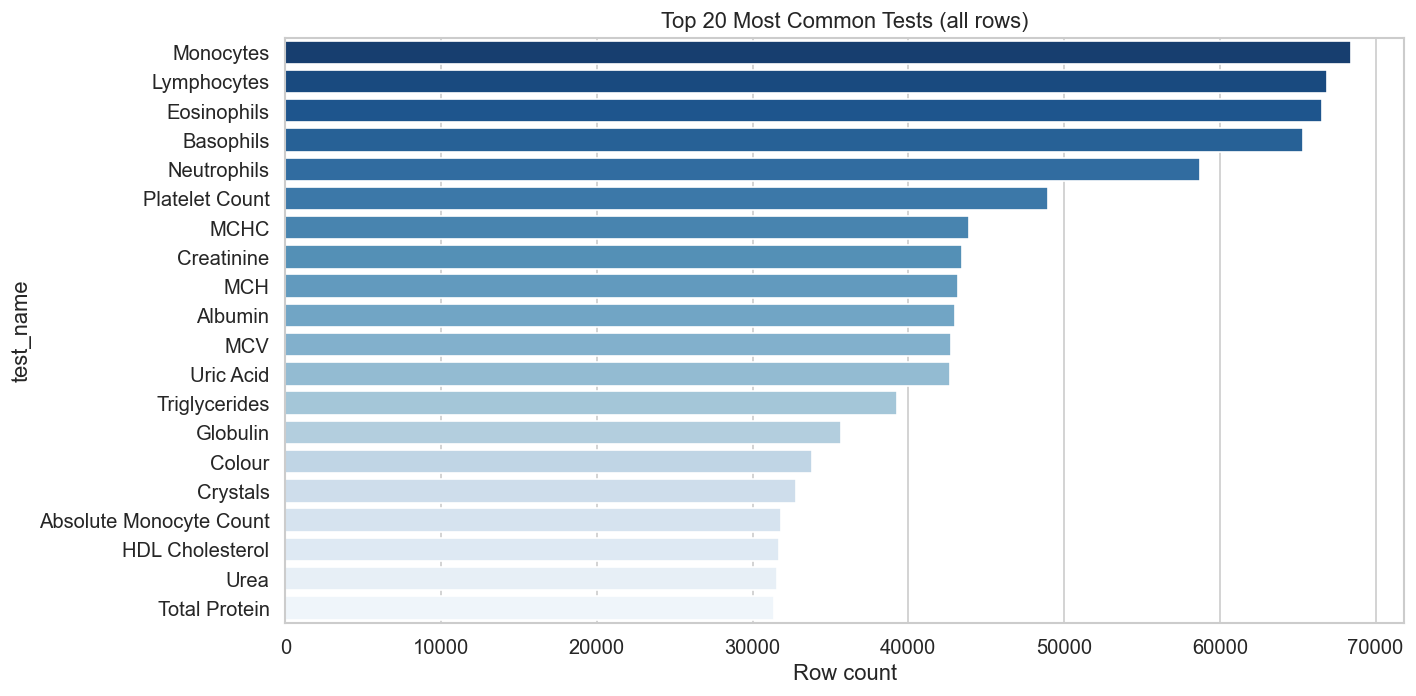

In [8]:
top20 = df['test_name'].value_counts().head(20)
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=top20.values, y=top20.index, palette='Blues_r', ax=ax)
ax.set_title('Top 20 Most Common Tests (all rows)')
ax.set_xlabel('Row count')
plt.tight_layout()
plt.savefig(f'{PLOTS}/top20_tests.png', bbox_inches='tight')
plt.show()

## 7. Missing-Value Heatmap (Top 30 Tests, 200-patient sample)

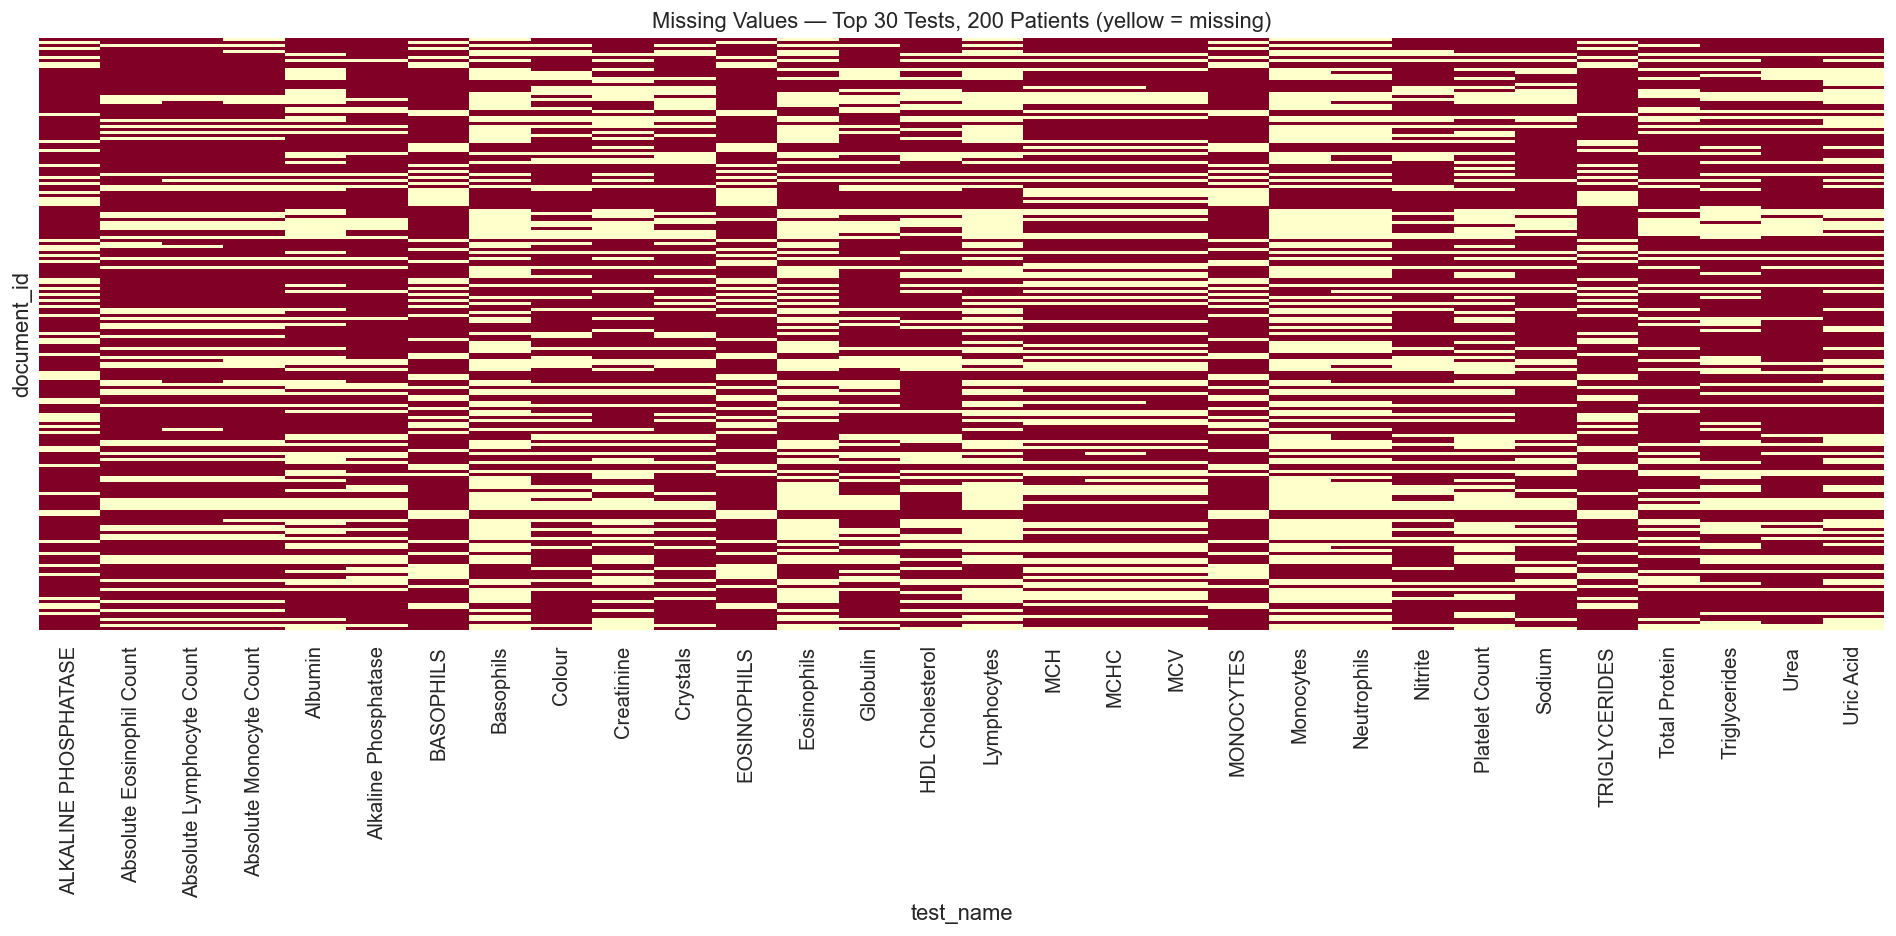

In [9]:
top30_tests = df['test_name'].value_counts().head(30).index.tolist()
sample_pts  = df['document_id'].drop_duplicates().sample(200, random_state=42)
df_sample   = df[df['document_id'].isin(sample_pts) & df['test_name'].isin(top30_tests)]
hm = df_sample.pivot_table(index='document_id', columns='test_name', values='value', aggfunc='first')

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(hm.isnull(), cmap='YlOrRd', cbar=False, ax=ax,
            xticklabels=True, yticklabels=False)
ax.set_title('Missing Values — Top 30 Tests, 200 Patients (yellow = missing)')
plt.tight_layout()
plt.savefig(f'{PLOTS}/missing_heatmap.png', bbox_inches='tight')
plt.show()

## 8. Display-Ranges Format Analysis

Categorise the `display_ranges` strings so `02_Preprocessing` knows which regex patterns to write.

Display-range pattern counts (n=500 sample):
display_ranges
X-Y range            339
Free text / other    107
<X                    48
>X                     5
Single value           1


C:\Users\Sreeansh Dash\AppData\Local\Temp\ipykernel_12164\2314510189.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dr_cats.values, y=dr_cats.index, palette='Set2', ax=ax)


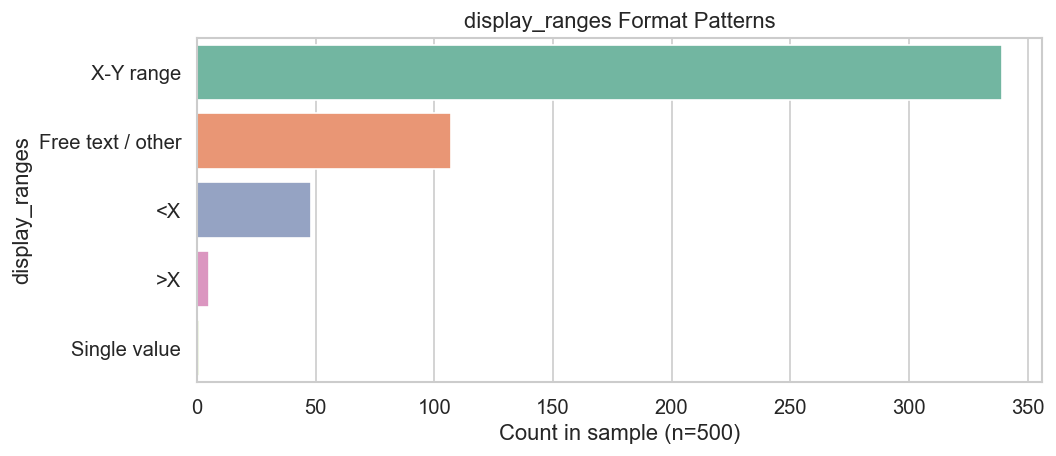


--- HbA1c display_ranges examples ---
display_ranges
4.0 - 5.6                                                                                                        7423
< 5.7                                                                                                            6276
impaired glucose tolerance:\n5.7-6.4\ndiabetes: > 6.5\nnon diabetic level: < 5.70                                5072
above 6.5 diabetes\nimpaired glucose tolerance:\n5.7-6.4\nbelow 5.6 non diabetic level                           1872
impaired glucose tolerance: 5.7\n6.4\ndiabetes: > 6.5\nnon diabetic level: < 5.70                                1542
non-diabetic: <= 5.6\npre-diabetic: 5.7-6.4\ndiabetic: >= 6.5                                                    1470
2.0 - 5.6                                                                                                        1417
non-diabetic: <= 5.6\npre-diabetic: 5.7-6.4\ndiabetic: >= 6.5\namerican diabetes association\nguidelines 2021    1359
4.

In [10]:
dr_sample = df['display_ranges'].dropna().sample(min(500, df['display_ranges'].notna().sum()), random_state=42)

def classify_range(s):
    s = str(s).strip()
    if re.fullmatch(r'[\d.]+\s*[-–]\s*[\d.]+', s):  return 'X-Y range'
    if re.match(r'^>\s*[\d.]', s):                   return '>X'
    if re.match(r'^<\s*[\d.]', s):                   return '<X'
    if re.match(r'(?i)^up\s*to\s*[\d.]', s):         return 'Up to X'
    if re.match(r'^[\d.]+$', s):                      return 'Single value'
    return 'Free text / other'

dr_cats = dr_sample.apply(classify_range).value_counts()
print('Display-range pattern counts (n=500 sample):')
print(dr_cats.to_string())

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(x=dr_cats.values, y=dr_cats.index, palette='Set2', ax=ax)
ax.set_title('display_ranges Format Patterns')
ax.set_xlabel('Count in sample (n=500)')
plt.tight_layout()
plt.savefig(f'{PLOTS}/display_ranges_patterns.png', bbox_inches='tight')
plt.show()

# HbA1c example
print('\n--- HbA1c display_ranges examples ---')
hba1c = df[df['test_name'].str.contains('HbA1c|Hba1c|hba1c|hemoglobin a1c', case=False, na=False)]
print(hba1c['display_ranges'].dropna().value_counts().head(10).to_string())

## 9. Unit Inconsistency Detection

For each `test_name`, count distinct units. Tests with many unit variants will need conversion in `02_Preprocessing`.

Top 20 tests by number of distinct units:
test_name
Platelet Count                529
PLATELET COUNT                470
RBC                           239
RBC Count                     230
Absolute Eosinophil Count     184
Absolute Lymphocyte Count     177
Absolute Monocyte Count       168
ESR                           164
Absolute Neutrophil Count     152
RBC COUNT                     150
Platelet count                144
Total WBC Count               138
Absolute Basophil Count       137
TOTAL RBC                     132
MCV                           124
NEUTROPHILS ABSOLUTE COUNT    122
WBC                           118
TOTAL LEUCOCYTES COUNT        115
Epithelial Cells              111
NUCLEATED RED BLOOD CELLS     110


C:\Users\Sreeansh Dash\AppData\Local\Temp\ipykernel_12164\1564078439.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=unit_var.values, y=unit_var.index, palette='Reds_r', ax=ax)


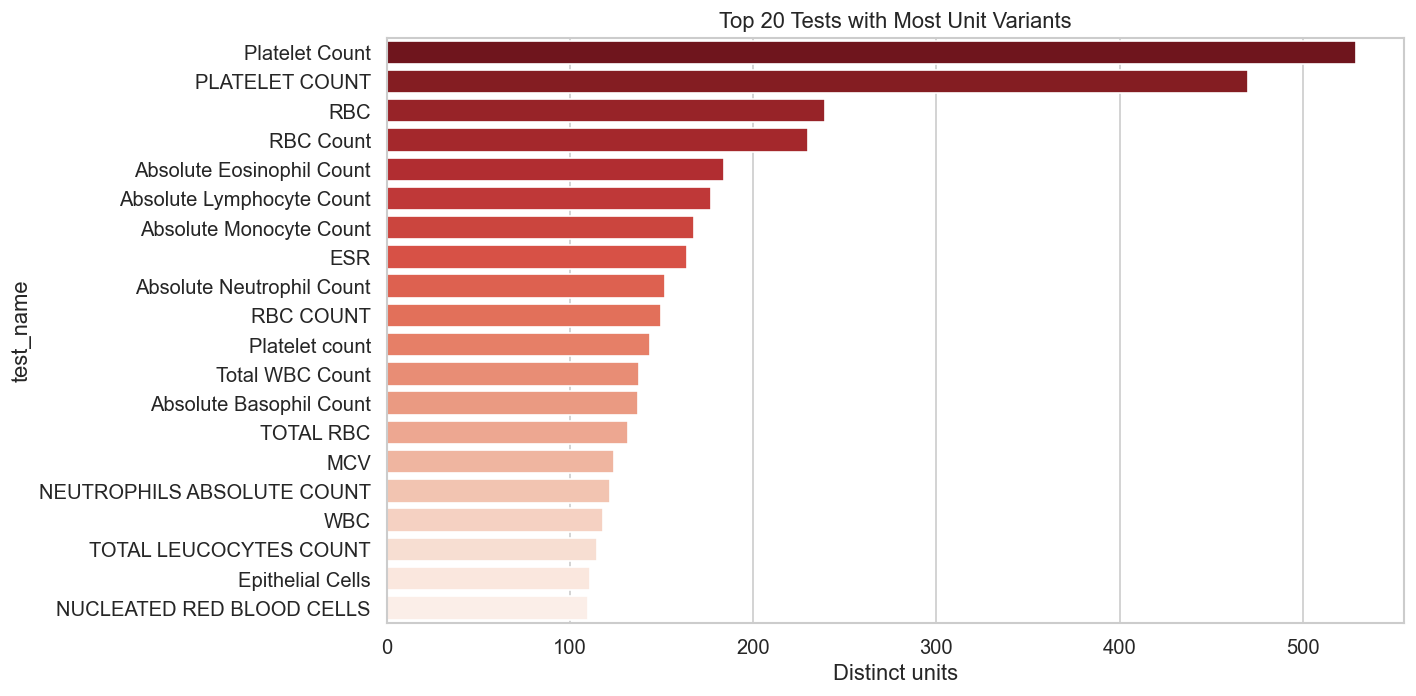


Platelet Count: [('10^3/ul', 8288), ('thou/mm3', 5958), ('thousand/uL', 4511), ('Thousand/uL', 4454), ('10^3/uL', 4209), ('/cmm', 2026), ('x10^3/uL', 1929), ('10^3/uI', 1632)]

PLATELET COUNT: [('X 10 ³ / uL', 3611), ('THOUSAND/uL', 2225), ('thou/uL', 2190), ('X 103/UL', 2186), ('X 10 superscrip', 2109), ('X 10³ /u L', 1599), ('cells/cu.mm', 1293), ('X (103/UL', 1046)]

RBC: [('/hpf', 2665), ('mili/cu.mm', 2419), ('10^6/cu.mm', 1741), ('/HPF', 1001), ('mil/cmm', 966), ('millions/cmm', 888), ('cells / HPF', 222), ('10^6/uL', 211)]


In [11]:
unit_var = (
    df.dropna(subset=['unit'])
      .groupby('test_name')['unit']
      .nunique()
      .sort_values(ascending=False)
      .head(20)
)
print('Top 20 tests by number of distinct units:')
print(unit_var.to_string())

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=unit_var.values, y=unit_var.index, palette='Reds_r', ax=ax)
ax.set_title('Top 20 Tests with Most Unit Variants')
ax.set_xlabel('Distinct units')
plt.tight_layout()
plt.savefig(f'{PLOTS}/unit_inconsistency.png', bbox_inches='tight')
plt.show()

# show actual unit values for the top 3 worst tests
worst3 = unit_var.head(3).index.tolist()
for t in worst3:
    units = df[df['test_name']==t]['unit'].value_counts()
    print(f'\n{t}: {list(units.items())[:8]}')

## 10. Specimen Type Distribution

Blood-related rows: 79.4%


C:\Users\Sreeansh Dash\AppData\Local\Temp\ipykernel_12164\1701188014.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=spec_counts.values, y=spec_counts.index, palette='Blues_r', ax=ax)


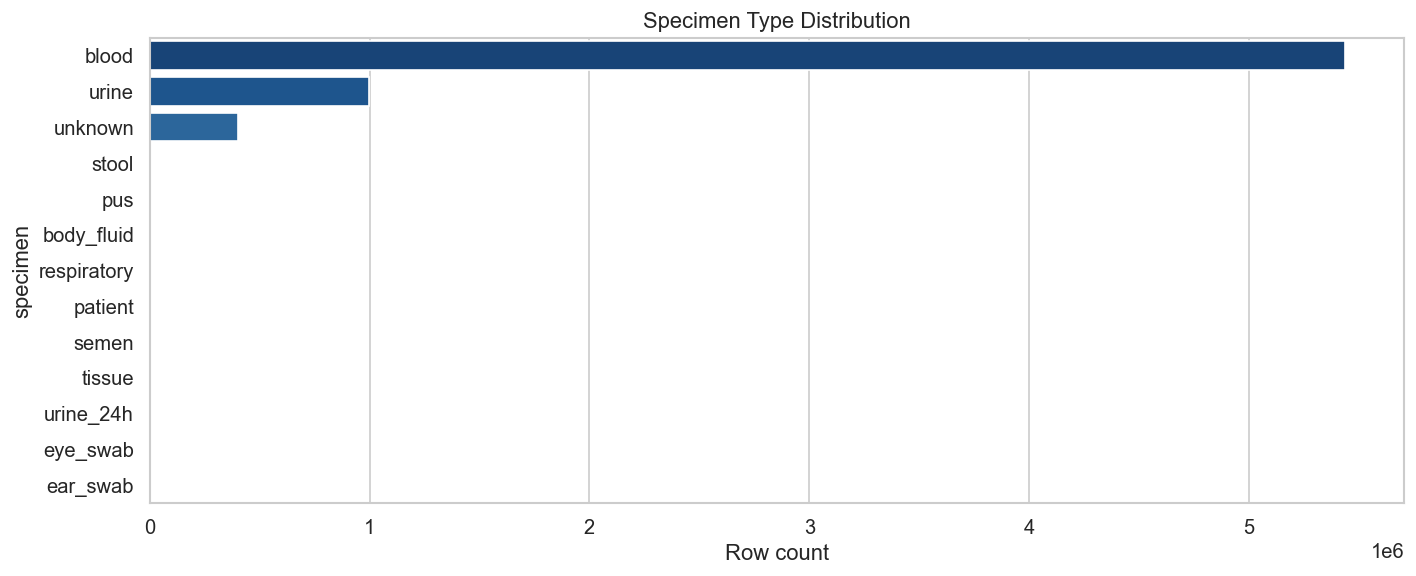

specimen
blood          5436575
urine           998723
unknown         400726
stool             4833
pus                973
body_fluid         763
respiratory        603
patient            493
semen              438
tissue             113
urine_24h           54
eye_swab             9
ear_swab             1


In [12]:
spec = df['specimen'].fillna('unknown').str.lower().str.strip()
spec_counts = spec.value_counts()
blood_types = ['blood', 'serum', 'plasma', 'whole blood']
blood_pct = spec.isin(blood_types).mean() * 100
print(f'Blood-related rows: {blood_pct:.1f}%')

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(x=spec_counts.values, y=spec_counts.index, palette='Blues_r', ax=ax)
ax.set_title('Specimen Type Distribution')
ax.set_xlabel('Row count')
plt.tight_layout()
plt.savefig(f'{PLOTS}/specimen_distribution.png', bbox_inches='tight')
plt.show()
print(spec_counts.to_string())

## 11. EDA Summary & Findings

### Key Findings
- **6.84 M rows**, 100 000 unique patients; long format (one row per test per patient)
- **Gender**: ~57% male, ~43% female
- **Specimen**: ~79% of rows are blood/serum/plasma — the rest (urine, stool, …) are filtered out in `02_Preprocessing`
- **Missing values**: `unit` (~15%), `display_ranges` (~11%), `loinc` (~7%), `specimen` (~6%)
- **Unit inconsistency**: Several tests (e.g., Platelet Count, WBC) have values reported in 2+ incompatible units across labs — unit normalisation is critical in preprocessing
- **display_ranges formats**: most follow `X-Y` numeric ranges; a minority use `>X`/`<X` or free text
- **Test coverage**: most patients have 20-80 tests; a long tail of patients with <10 tests

### Train / Test Split — SAVED

| File | Path | Rows (approx) |
|------|------|---------------|
| `train_ids.csv` | `data/splits/train_ids.csv` | ~80 000 patients |
| `test_ids.csv`  | `data/splits/test_ids.csv`  | ~20 000 patients |

> **Rule for all downstream notebooks (02–05):**  
> Load `train_ids.csv` and `test_ids.csv` at the top, then split the data immediately.  
> **Do NOT call `train_test_split` again.** The split was stratified by gender × age group with `random_state=42`.